In [ ]:
import pandas as pd

# Load our selected dataset
df = pd.read_csv("/content/cloud_anomaly_selected.csv")

# Display basic information
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nTarget distribution:")
print(df["anomaly"].value_counts())

Dataset shape: (10080, 10)

Columns:
['time', 'node_cpu_utilization|Average|node1', 'node_cpu_utilization|Average|node2', 'pod_memory_utilization|Average|carts-db', 'pod_network_rx_bytes|Average|user', 'carts_req_rate', 'user_req_rate', 'orders_perc95_rt', 'front-end_perc95_rt', 'anomaly']

First 5 rows:


,time,node_cpu_utilization|Average|node1,node_cpu_utilization|Average|node2,pod_memory_utilization|Average|carts-db,pod_network_rx_bytes|Average|user,carts_req_rate,user_req_rate,orders_perc95_rt,front-end_perc95_rt,anomaly
0,2024-05-13 15:53:00+00:00,5.439496,4.510725,5.986152,6179.254392,1.000000,0.999001,45.000000,115.000000,0
1,2024-05-13 15:54:00+00:00,8.577096,5.246745,5.987876,19966.358461,4.006012,18.000000,46.125000,118.342391,0
2,2024-05-13 15:55:00+00:00,9.070289,5.870836,5.990007,25264.919260,6.000000,30.964143,72.291236,111.715618,0
3,2024-05-13 15:56:00+00:00,8.499096,5.736410,5.988789,21704.959219,6.000000,9.018054,52.999127,99.297945,0
4,2024-05-13 15:57:00+00:00,9.059439,5.641050,5.988485,23946.192840,5.000000,0.994036,47.736486,99.268293,0



Target distribution:
anomaly
0    9309
1     771
Name: count, dtype: int64


In [ ]:
# Basic data quality checks

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nTime sorted:", pd.to_datetime(df["time"]).is_monotonic_increasing)

print("\nBasic statistics:")
display(df.describe())

Missing values:
time                                       0
node_cpu_utilization|Average|node1         0
node_cpu_utilization|Average|node2         0
pod_memory_utilization|Average|carts-db    0
pod_network_rx_bytes|Average|user          0
carts_req_rate                             0
user_req_rate                              0
orders_perc95_rt                           0
front-end_perc95_rt                        0
anomaly                                    0
dtype: int64

Duplicate rows: 0

Data types:
time                                        object
node_cpu_utilization|Average|node1         float64
node_cpu_utilization|Average|node2         float64
pod_memory_utilization|Average|carts-db    float64
pod_network_rx_bytes|Average|user          float64
carts_req_rate                             float64
user_req_rate                              float64
orders_perc95_rt                           float64
front-end_perc95_rt                        float64
anomaly                       

,node_cpu_utilization|Average|node1,node_cpu_utilization|Average|node2,pod_memory_utilization|Average|carts-db,pod_network_rx_bytes|Average|user,carts_req_rate,user_req_rate,orders_perc95_rt,front-end_perc95_rt,anomaly
count,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000
mean,11.017406,5.685086,4.652380,20387.712049,5.648162,11.184430,106.170558,183.516171,0.076488
std,5.980170,3.656719,1.171595,5246.569965,3.857274,9.834678,308.506279,188.496420,0.265791
min,4.265116,3.278341,2.680658,547.606580,0.000000,0.000000,0.475000,0.475217,0.000000
25%,7.401529,5.190408,4.086743,17668.538579,3.000000,2.000000,48.541667,129.930670,0.000000
50%,9.627872,5.452385,4.832021,20196.988718,5.000000,9.000000,74.000000,183.534226,0.000000
75%,13.105726,5.699562,4.970837,22833.802737,8.000000,17.000000,93.750000,209.408815,0.000000
max,99.989965,99.988482,31.806784,56577.726939,38.012048,102.303912,9604.398943,5537.401575,1.000000


In [ ]:
# Compare feature averages between Normal and Anomalous observations

feature_columns = [
    "node_cpu_utilization|Average|node1",
    "node_cpu_utilization|Average|node2",
    "pod_memory_utilization|Average|carts-db",
    "pod_network_rx_bytes|Average|user",
    "carts_req_rate",
    "user_req_rate",
    "orders_perc95_rt",
    "front-end_perc95_rt"
]

comparison = df.groupby("anomaly")[feature_columns].mean().T

comparison.columns = ["Normal (0)", "Anomalous (1)"]

display(comparison)

,Normal (0),Anomalous (1)
node_cpu_utilization|Average|node1,10.568407,16.438592
node_cpu_utilization|Average|node2,5.451812,8.501625
pod_memory_utilization|Average|carts-db,4.614731,5.106960
pod_network_rx_bytes|Average|user,20063.160902,24306.319868
carts_req_rate,5.563987,6.664490
user_req_rate,10.999056,13.422626
orders_perc95_rt,79.919512,423.123847
front-end_perc95_rt,168.742759,361.889319


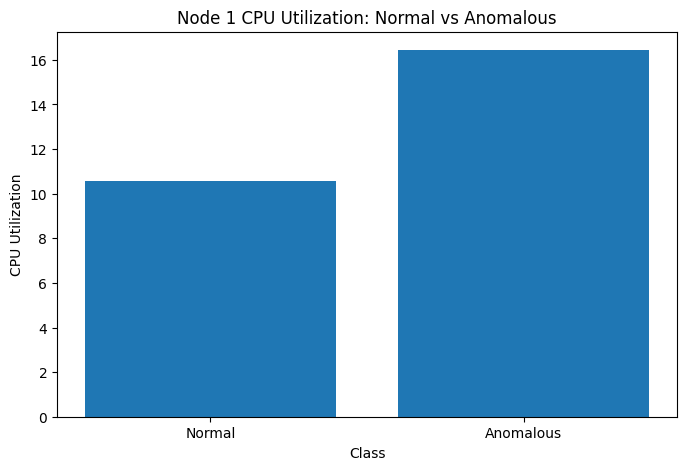

In [ ]:
import matplotlib.pyplot as plt

# Calculate average values for Normal and Anomalous observations
comparison = df.groupby("anomaly")[feature_columns].mean()

# Plot CPU utilization
plt.figure(figsize=(8, 5))

plt.bar(
    ["Normal", "Anomalous"],
    [
        comparison.loc[0, "node_cpu_utilization|Average|node1"],
        comparison.loc[1, "node_cpu_utilization|Average|node1"]
    ]
)

plt.title("Node 1 CPU Utilization: Normal vs Anomalous")
plt.xlabel("Class")
plt.ylabel("CPU Utilization")
plt.show()

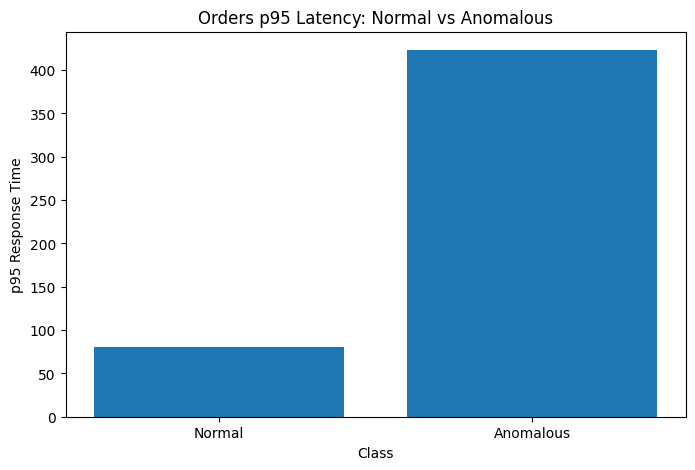

In [ ]:
# Compare Orders p95 latency for Normal vs Anomalous observations

plt.figure(figsize=(8, 5))

plt.bar(
    ["Normal", "Anomalous"],
    [
        comparison.loc[0, "orders_perc95_rt"],
        comparison.loc[1, "orders_perc95_rt"]
    ]
)

plt.title("Orders p95 Latency: Normal vs Anomalous")
plt.xlabel("Class")
plt.ylabel("p95 Response Time")
plt.show()

In [ ]:
# Correlation between selected features

correlation = df[feature_columns].corr()

display(correlation.round(2))

,node_cpu_utilization|Average|node1,node_cpu_utilization|Average|node2,pod_memory_utilization|Average|carts-db,pod_network_rx_bytes|Average|user,carts_req_rate,user_req_rate,orders_perc95_rt,front-end_perc95_rt
node_cpu_utilization|Average|node1,1.00,0.03,0.42,0.24,0.12,0.08,0.08,0.12
node_cpu_utilization|Average|node2,0.03,1.00,0.00,0.08,0.04,0.04,0.00,0.00
pod_memory_utilization|Average|carts-db,0.42,0.00,1.00,0.06,0.03,0.01,0.03,0.09
pod_network_rx_bytes|Average|user,0.24,0.08,0.06,1.00,0.36,0.31,-0.00,0.02
carts_req_rate,0.12,0.04,0.03,0.36,1.00,0.52,-0.00,0.01
user_req_rate,0.08,0.04,0.01,0.31,0.52,1.00,-0.01,-0.00
orders_perc95_rt,0.08,0.00,0.03,-0.00,-0.00,-0.01,1.00,0.43
front-end_perc95_rt,0.12,0.00,0.09,0.02,0.01,-0.00,0.43,1.00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert time to datetime
df["time"] = pd.to_datetime(df["time"])

# Chronological 80/20 split
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

# Input features
X_train = train_df[feature_columns]
X_test = test_df[feature_columns]

# Target
y_train = train_df["anomaly"]
y_test = test_df["anomaly"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

X_train shape: (8064, 8)
X_test shape: (2016, 8)
y_train shape: (8064,)
y_test shape: (2016,)

Training classes:
anomaly
0    7420
1     644
Name: count, dtype: int64

Testing classes:
anomaly
0    1889
1     127
Name: count, dtype: int64


In [ ]:
# Create and fit the scaler using ONLY training data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nFirst training row before scaling:")
print(X_train.iloc[0].values)

print("\nFirst training row after scaling:")
print(X_train_scaled[0])

Scaled training shape: (8064, 8)
Scaled testing shape: (2016, 8)

First training row before scaling:
[5.43949603e+00 4.51072503e+00 5.98615194e+00 6.17925439e+03
 1.00000000e+00 9.99000999e-01 4.50000000e+01 1.15000000e+02]

First training row after scaling:
[-1.09436197 -0.35860195  1.0900753  -2.67516568 -1.21452777 -1.03612976
 -0.21706991 -0.33247368]


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

# Train the model
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test data

y_pred = model.predict(X_test_scaled)

# Probability of being anomalous
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions created successfully!")

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 anomaly probabilities:")
print(y_prob[:10])

Predictions created successfully!

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 anomaly probabilities:
[0.04680818 0.04725177 0.04032135 0.03691277 0.0454431  0.05440067
 0.03940414 0.04106328 0.04379986 0.04073311]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation
-----------------
Accuracy : 0.9633
Precision: 0.8630
Recall   : 0.4961
F1-score : 0.6300
ROC-AUC  : 0.8820

Confusion Matrix:
[[1879   10]
 [  64   63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1889
           1       0.86      0.50      0.63       127

    accuracy                           0.96      2016
   macro avg       0.92      0.75      0.81      2016
weighted avg       0.96      0.96      0.96      2016



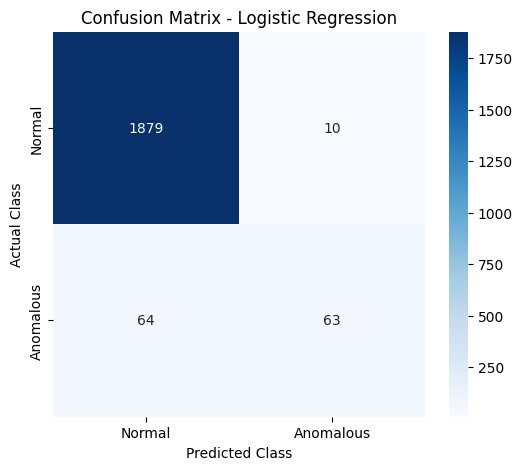

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomalous"],
    yticklabels=["Normal", "Anomalous"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

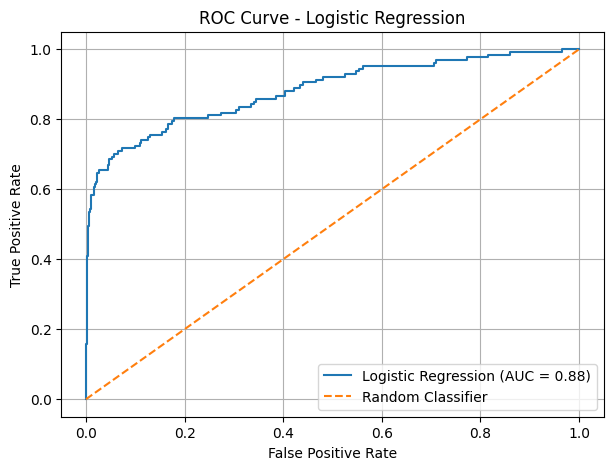

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Feature importance from Logistic Regression coefficients

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": model.coef_[0]
})

# Absolute coefficient = strength of contribution
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(feature_importance)

,Feature,Coefficient,Absolute_Coefficient
1,node_cpu_utilization|Average|node2,2.319550,2.319550
6,orders_perc95_rt,1.022020,1.022020
7,front-end_perc95_rt,0.495022,0.495022
0,node_cpu_utilization|Average|node1,0.319371,0.319371
3,pod_network_rx_bytes|Average|user,0.230320,0.230320
4,carts_req_rate,-0.069166,0.069166
5,user_req_rate,0.008760,0.008760
2,pod_memory_utilization|Average|carts-db,0.007022,0.007022


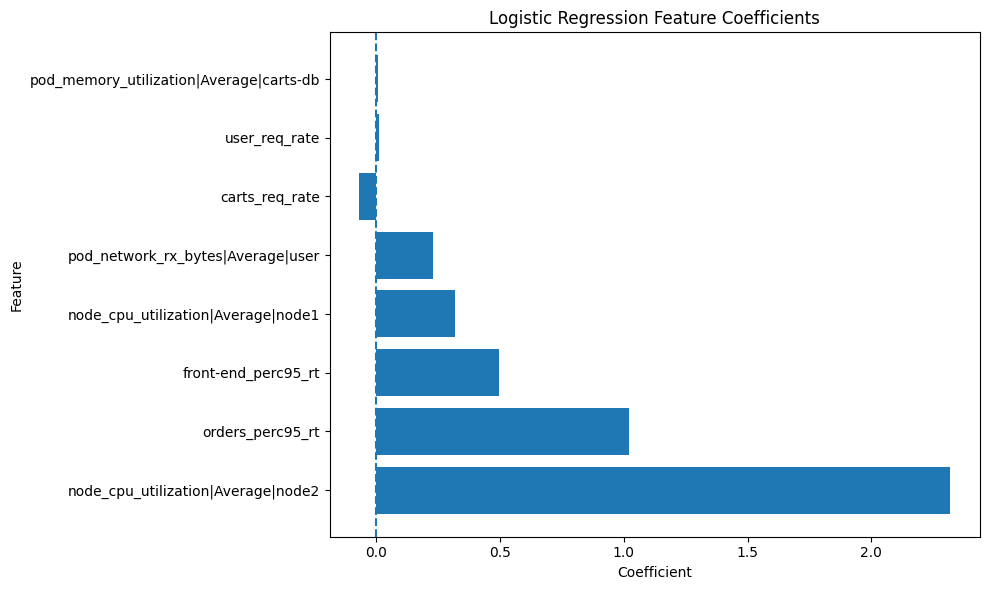

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
tree_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# Train using original, unscaled features
tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# Make predictions using Decision Tree

tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions created successfully!")

print("\nFirst 10 predicted classes:")
print(tree_pred[:10])

print("\nFirst 10 anomaly probabilities:")
print(tree_prob[:10])

Decision Tree predictions created successfully!

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 anomaly probabilities:
[0.22546667 0.22546667 0.22546667 0.22546667 0.22546667 0.22546667
 0.22546667 0.22546667 0.22546667 0.22546667]


In [ ]:
# Evaluate Decision Tree

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred, zero_division=0)
tree_recall = recall_score(y_test, tree_pred, zero_division=0)
tree_f1 = f1_score(y_test, tree_pred, zero_division=0)
tree_roc_auc = roc_auc_score(y_test, tree_prob)
tree_cm = confusion_matrix(y_test, tree_pred)

print("Decision Tree Evaluation")
print("------------------------")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1-score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(tree_cm)

print("\nClassification Report:")
print(classification_report(y_test, tree_pred, zero_division=0))

Decision Tree Evaluation
------------------------
Accuracy : 0.9544
Precision: 0.7160
Recall   : 0.4567
F1-score : 0.5577
ROC-AUC  : 0.7960

Confusion Matrix:
[[1866   23]
 [  69   58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1889
           1       0.72      0.46      0.56       127

    accuracy                           0.95      2016
   macro avg       0.84      0.72      0.77      2016
weighted avg       0.95      0.95      0.95      2016



In [ ]:
# Compare Logistic Regression and Decision Tree

comparison_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_roc_auc
    ]
})

display(comparison_results.round(4))

,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.9633,0.9544
1,Precision,0.8630,0.7160
2,Recall,0.4961,0.4567
3,F1-score,0.6300,0.5577
4,ROC-AUC,0.8820,0.7960


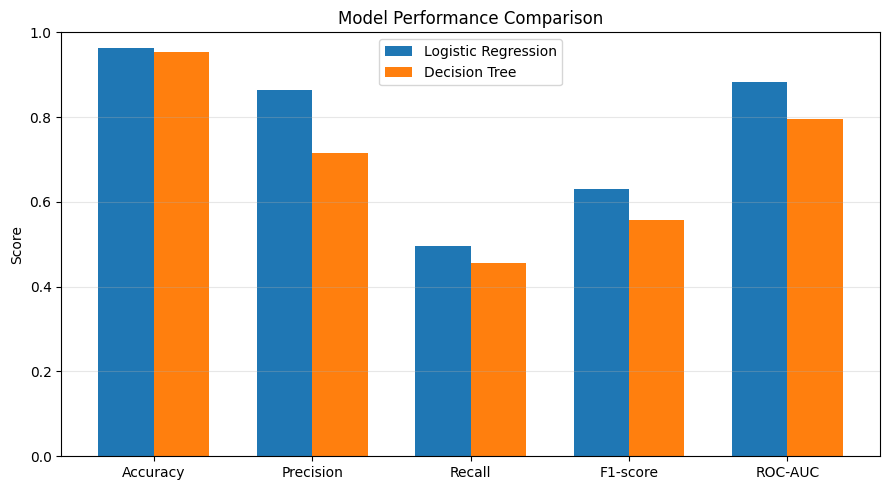

In [ ]:
plt.figure(figsize=(9, 5))

x = range(len(comparison_results["Metric"]))
width = 0.35

plt.bar(
    [i - width/2 for i in x],
    comparison_results["Logistic Regression"],
    width=width,
    label="Logistic Regression"
)

plt.bar(
    [i + width/2 for i in x],
    comparison_results["Decision Tree"],
    width=width,
    label="Decision Tree"
)

plt.xticks(x, comparison_results["Metric"])
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import joblib

model_package = {
    "model": model,
    "scaler": scaler,
    "features": feature_columns
}

joblib.dump(
    model_package,
    "/content/cloud_anomaly_model.pkl"
)

print("Model saved successfully!")
print("File: /content/cloud_anomaly_model.pkl")

Model saved successfully!
File: /content/cloud_anomaly_model.pkl


In [ ]:
from google.colab import files

files.download("/content/cloud_anomaly_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>